In [1]:
import numpy as np
import pickle as pkl
import matplotlib.pyplot as plt

In [7]:
# Loading in data
ground_truth = pkl.load(open('../data/spring_mass/static_graph/graphs/trial_0.pkl', 'rb'))

Acceleration over time

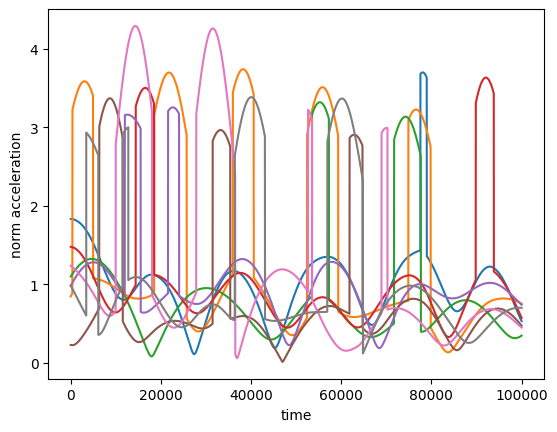

In [8]:
acc_over_time_norm = [np.linalg.norm(i.acc, axis=1) for i in ground_truth]
fig, axs = plt.subplots()
axs.plot(range(len(acc_over_time_norm)), acc_over_time_norm)
axs.set_xlabel('time')
axs.set_ylabel('norm acceleration')
plt.show()

Velocity over time

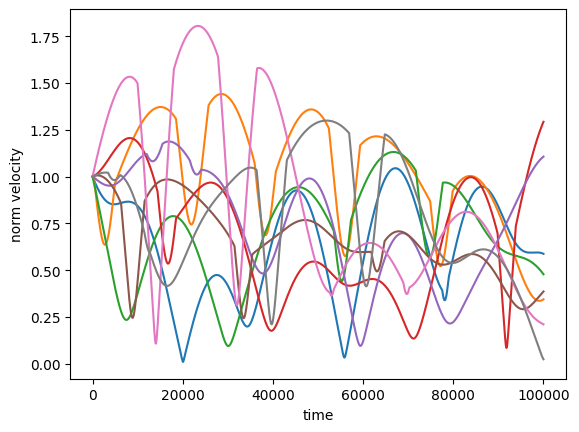

In [9]:
vel_over_time_norm = [np.linalg.norm(i.vel, axis=1) for i in ground_truth]
fig, axs = plt.subplots()
axs.plot(range(len(vel_over_time_norm)), vel_over_time_norm)
axs.set_xlabel('time')
axs.set_ylabel('norm velocity')
plt.show()

Position over time

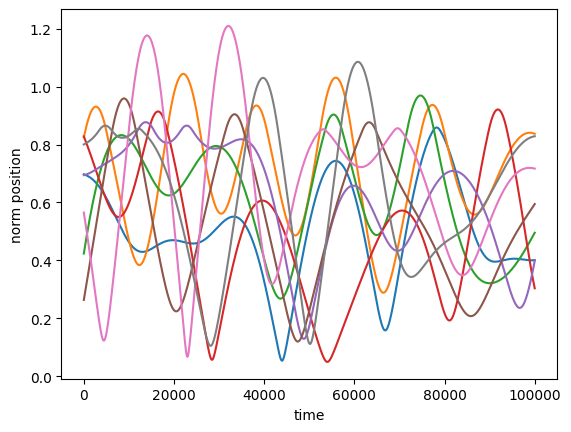

In [10]:
pos_over_time_norm = [np.linalg.norm(i.pos, axis=1) for i in ground_truth]
fig, axs = plt.subplots()
axs.plot(range(len(pos_over_time_norm)), pos_over_time_norm)
axs.set_xlabel('time')
axs.set_ylabel('norm position')
plt.show()

norm jerk

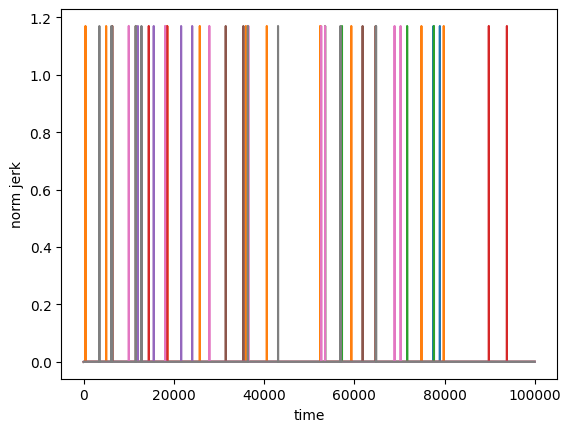

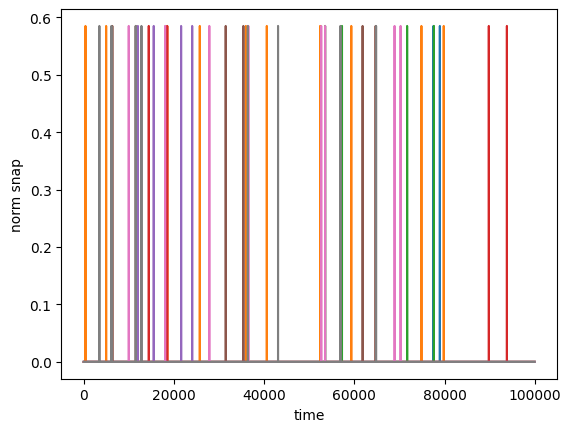

In [11]:
acc_over_time = [i.acc for i in ground_truth]
jerk_over_time = np.gradient(np.array(acc_over_time), axis=0)
snap_over_time = np.gradient(jerk_over_time, axis=0)

jerk_over_time_norm = [np.linalg.norm(i, axis=1) for i in jerk_over_time]
snap_over_time_norm = [np.linalg.norm(i, axis=1) for i in snap_over_time]

fig, axs = plt.subplots()
axs.plot(range(len(jerk_over_time_norm)), jerk_over_time_norm)
axs.set_xlabel('time')
axs.set_ylabel('norm jerk')
plt.show()

fig, axs = plt.subplots()
axs.plot(range(len(snap_over_time_norm)), snap_over_time_norm)
axs.set_xlabel('time')
axs.set_ylabel('norm snap')
plt.show()

Plotting predicted acceleration vs. actual acceleration

In [8]:
import torch
import yaml
from models import models
from tqdm import tqdm

def get_pred_acc(config, state_dict):
    device = torch.device(f'cuda' if torch.cuda.is_available() else "cpu")
    print(device)

    # getting GNN prediction of acceleration over time
    config = yaml.safe_load(open(config, 'r'))
    state_dict = torch.load(state_dict, map_location=device)

    # init model
    model = models.LearnedSimModel(
        graph_edge_dim=ground_truth[0].edge_attr.shape[1],
        graph_node_dim=ground_truth[0].x.shape[1],
        config=config
    ).to(device)
    model.load_state_dict(state_dict=state_dict)
    model.eval()

    # get acceleration predictions
    with torch.no_grad():
        pred_acc_list = []
        running_loss = []
        for i in tqdm(ground_truth):
            i.to(device)
            
            # make sure to use ground truth edges if needed
            if config['training']['gt_edges']:
                i.edge_index = i.gt_edge_index
                i.edge_attr = i.gt_edge_attr

            pred_acc = model(i)
            pred_acc_list.append(pred_acc)

            # record loss
            loss = torch.nn.functional.mse_loss(pred_acc, i.acc)
            running_loss.append(loss.item())
        
        print(f'avg loss: {sum(running_loss) / len(running_loss)}')

    return torch.stack(pred_acc_list)

# pred Acc model
# acc_pred_acc = get_pred_acc(config='../results/SpringMass/GPS/model/gt_edges_pred_acc_no_rollout_val/trial_0_config.yaml', state_dict='../results/SpringMass/GPS/model/gt_edges_pred_acc_no_rollout_val/trial_0.pt')
# acc_pred_pos = get_pred_acc(config='../_dt_sweep_experiment/results/model/dt256/trial_0_config.yaml', state_dict='../_dt_sweep_experiment/results/model/dt256/trial_0.pt')

In [9]:
# get test rollout and acceleration loss
pred_acc_directly = get_pred_acc(config='../results/SpringMass/GPS/model/gt_edges_pred_acc_no_rollout_val/trial_0_config.yaml', state_dict='../results/SpringMass/GPS/model/gt_edges_pred_acc_no_rollout_val/trial_0.pt')
rollout_pred_acc_directly = pkl.load(open('../results/SpringMass/GPS/model/gt_edges_pred_acc_no_rollout_val/trial_0_rollout_preds.pkl', 'rb'))
pred_pos_no_rollout_acc = get_pred_acc(config='../results/SpringMass/GPS/model/gt_edges_pred_pos_no_rollout_val/trial_0_config.yaml', state_dict='../results/SpringMass/GPS/model/gt_edges_pred_pos_no_rollout_val/trial_0.pt')
rollout_pred_pos_no_rollout_acc = pkl.load(open('../results/SpringMass/GPS/model/gt_edges_pred_pos_no_rollout_val/trial_0_rollout_preds.pkl', 'rb'))
dt256 = get_pred_acc(config='../_dt_sweep_experiment/results/model/dt256/trial_0_config.yaml', state_dict='../_dt_sweep_experiment/results/model/dt256/trial_0.pt')
rollout_dt256 = pkl.load(open('../_dt_sweep_experiment/results/model/dt256/trial_0_rollout_preds.pkl', 'rb'))
dt1 = get_pred_acc(config='../_dt_sweep_experiment/results/model/dt1/trial_0_config.yaml', state_dict='../_dt_sweep_experiment/results/model/dt1/trial_0.pt')
rollout_dt1 = pkl.load(open('../_dt_sweep_experiment/results/model/dt1/trial_0_rollout_preds.pkl', 'rb'))

cuda


100%|██████████| 100000/100000 [04:24<00:00, 377.85it/s]


avg loss: 0.054581069360354596
cuda


100%|██████████| 100000/100000 [04:35<00:00, 363.41it/s]


avg loss: 0.050428310377091404
cuda


100%|██████████| 100000/100000 [04:29<00:00, 370.64it/s]


avg loss: 0.08288434400274884
cuda


100%|██████████| 100000/100000 [04:26<00:00, 375.12it/s]


avg loss: 1.0086294602372496


In [40]:
torch.stack(rollout_pred_acc_directly).shape

torch.Size([78, 8, 2])

Pred Acc Directly
torch.Size([100000, 8, 2])
torch.Size([20000, 8, 2])
torch.Size([20000, 8, 2])
Pred Pos (No Rollout validation)
torch.Size([100000, 8, 2])
torch.Size([20000, 8, 2])
torch.Size([20000, 8, 2])
dt=256
torch.Size([100000, 8, 2])
torch.Size([20000, 8, 2])
torch.Size([20000, 8, 2])
dt=1
torch.Size([100000, 8, 2])
torch.Size([20000, 8, 2])
torch.Size([20000, 8, 2])


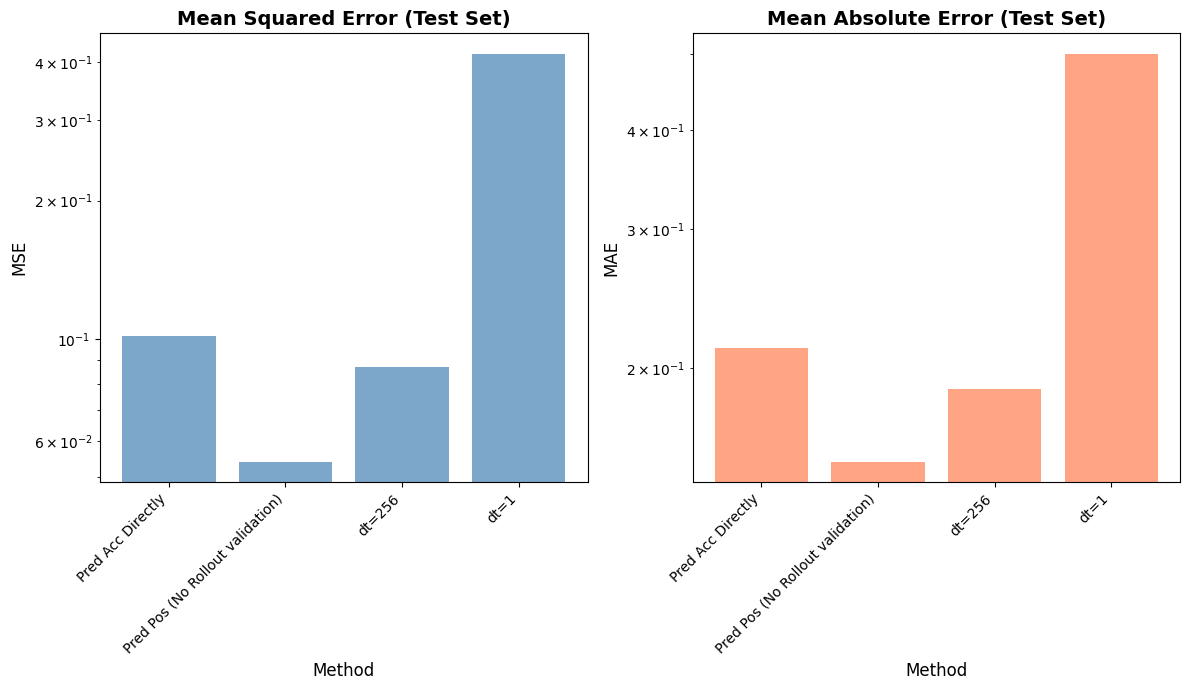


ACCELERATION PREDICTION PERFORMANCE (Test Set)

Pred Acc Directly:
  MSE: 1.017720e-01
  MAE: 2.121820e-01

Pred Pos (No Rollout validation):
  MSE: 5.401858e-02
  MAE: 1.521535e-01

dt=256:
  MSE: 8.705483e-02
  MAE: 1.882652e-01

dt=1:
  MSE: 4.176665e-01
  MAE: 4.999533e-01


In [41]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def compute_acceleration_from_positions(positions, dt=1.0):
    """
    Compute acceleration from positions using finite differences.
    positions: [time, mass, 2] tensor
    """
    # Compute velocity: v = (x[t+1] - x[t]) / dt
    velocity = (positions[1:] - positions[:-1]) / dt
    
    # Compute acceleration: a = (v[t+1] - v[t]) / dt
    acceleration = (velocity[1:] - velocity[:-1]) / dt
    
    return acceleration

def compute_acceleration_metrics(pred_positions, gt_acceleration, start_idx=-20000):
    """
    Compute MSE and MAE between predicted and ground truth acceleration.
    """
    # Extract test data
    pred_test = pred_positions[start_idx:]
    gt_test = gt_acceleration[start_idx:]

    print(pred_test.shape)
    print(gt_test.shape)
    
    # Compute metrics
    mse = torch.mean((pred_test - gt_test) ** 2).item()
    mae = torch.mean(torch.abs(pred_test - gt_test)).item()
    
    return mse, mae, pred_test

# Compute metrics for all methods
methods = {
    'Pred Acc Directly': pred_acc_directly,
    # 'Pred Acc (Rollout)': rollout_pred_acc_directly,
    'Pred Pos (No Rollout validation)': pred_pos_no_rollout_acc,
    # 'Pred Pos (Rollout)': rollout_pred_pos_no_rollout_acc,
    'dt=256': dt256,
    # 'dt=256 (Rollout)': rollout_dt256,
    'dt=1': dt1,
    # 'dt=1 (Rollout)': rollout_dt1,
}

results = {}
for name, predictions in methods.items():
    print(name)
    print(predictions.shape)
    mse, mae, pred_acc = compute_acceleration_metrics(predictions.cpu(), torch.stack(acc_over_time))
    results[name] = {'MSE': mse, 'MAE': mae, 'pred_acc': pred_acc}

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Plot 1: MSE comparison
ax1 = axes[0]
names = list(results.keys())
mse_values = [results[name]['MSE'] for name in names]
bars1 = ax1.bar(range(len(names)), mse_values, alpha=0.7, color='steelblue')
ax1.set_xlabel('Method', fontsize=12)
ax1.set_ylabel('MSE', fontsize=12)
ax1.set_title('Mean Squared Error (Test Set)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(names)))
ax1.set_xticklabels(names, rotation=45, ha='right')
ax1.set_yscale('log')  # Log scale often useful for MSE

# Plot 2: MAE comparison
ax2 = axes[1]
mae_values = [results[name]['MAE'] for name in names]
bars2 = ax2.bar(range(len(names)), mae_values, alpha=0.7, color='coral')
ax2.set_xlabel('Method', fontsize=12)
ax2.set_ylabel('MAE', fontsize=12)
ax2.set_title('Mean Absolute Error (Test Set)', fontsize=14, fontweight='bold')
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)
ax2.set_yscale('log')  # Log scale often useful for MAE

# # Plot 3: Sample trajectory comparison (for one mass, x-direction)
# ax3 = axes[1]
# sample_length = 500  # Show first 500 timesteps of test set
# mass_idx = 0  # First mass
# coord_idx = 0  # x-coordinate

# gt_sample = results[names[0]]['gt_acc'][:sample_length, mass_idx, coord_idx].cpu().numpy()
# ax3.plot(gt_sample, 'k-', linewidth=2, label='Ground Truth', alpha=0.8)

# colors = plt.cm.tab10(np.linspace(0, 1, len(names)))
# for i, name in enumerate(names[:4]):  # Plot first 4 methods to avoid clutter
#     pred_sample = results[name]['pred_acc'][:sample_length, mass_idx, coord_idx].cpu().numpy()
#     ax3.plot(pred_sample, '--', linewidth=1.5, label=name, alpha=0.7, color=colors[i])

# ax3.set_xlabel('Time Step', fontsize=12)
# ax3.set_ylabel('Acceleration (x)', fontsize=12)
# ax3.set_title(f'Sample Trajectory (Mass {mass_idx}, x-coord)', fontsize=14, fontweight='bold')
# ax3.legend(fontsize=9)
# ax3.grid(alpha=0.3)

# # Plot 4: Relative error (percentage)
# ax4 = axes[1, 1]
# relative_errors = []
# for name in names:
#     pred_acc = results[name]['pred_acc']
#     gt_acc = results[name]['gt_acc']
#     relative_error = torch.mean(torch.abs(pred_acc - gt_acc) / (torch.abs(gt_acc) + 1e-8)).item() * 100
#     relative_errors.append(relative_error)

# bars4 = ax4.bar(range(len(names)), relative_errors, alpha=0.7, color='mediumseagreen')
# ax4.set_xlabel('Method', fontsize=12)
# ax4.set_ylabel('Relative Error (%)', fontsize=12)
# ax4.set_title('Mean Relative Error (Test Set)', fontsize=14, fontweight='bold')
# ax4.set_xticks(range(len(names)))
# ax4.set_xticklabels(names, rotation=45, ha='right')
# ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('acceleration_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("ACCELERATION PREDICTION PERFORMANCE (Test Set)")
print("="*70)
for name in names:
    print(f"\n{name}:")
    print(f"  MSE: {results[name]['MSE']:.6e}")
    print(f"  MAE: {results[name]['MAE']:.6e}")

In [ ]:
# plotting acceleration loss for test data
acc_loss = {
    'acc_directly': None,
}

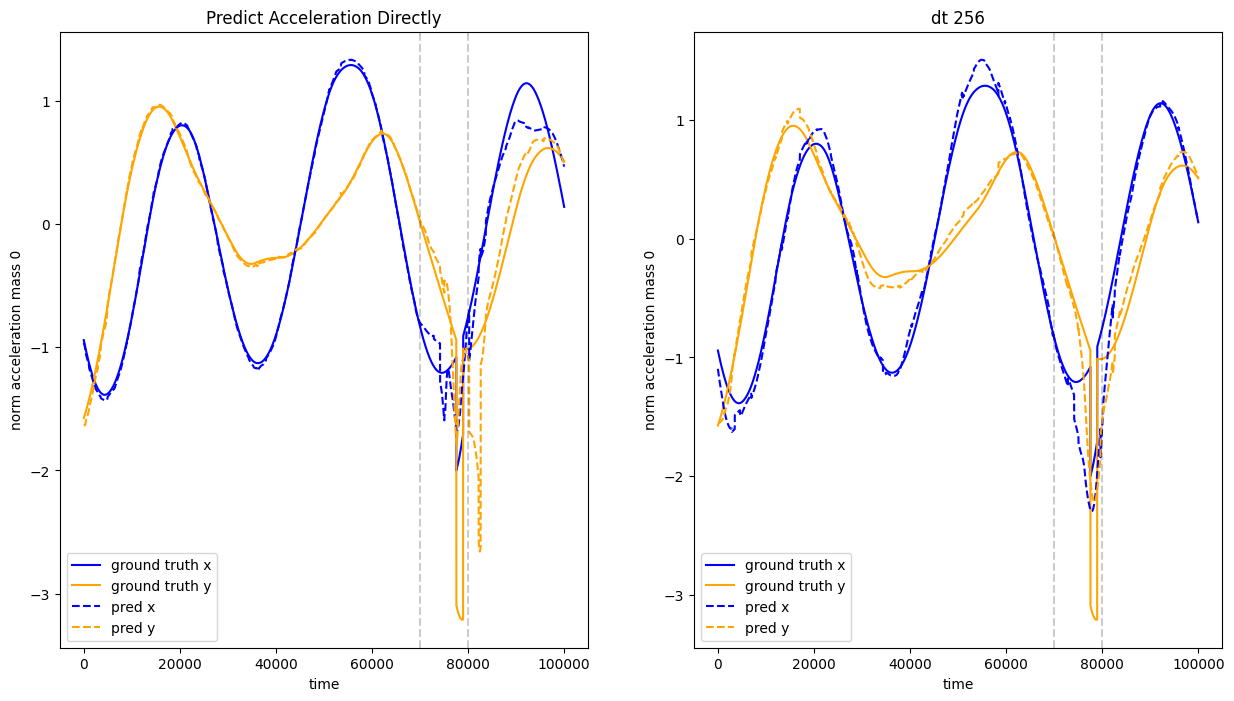

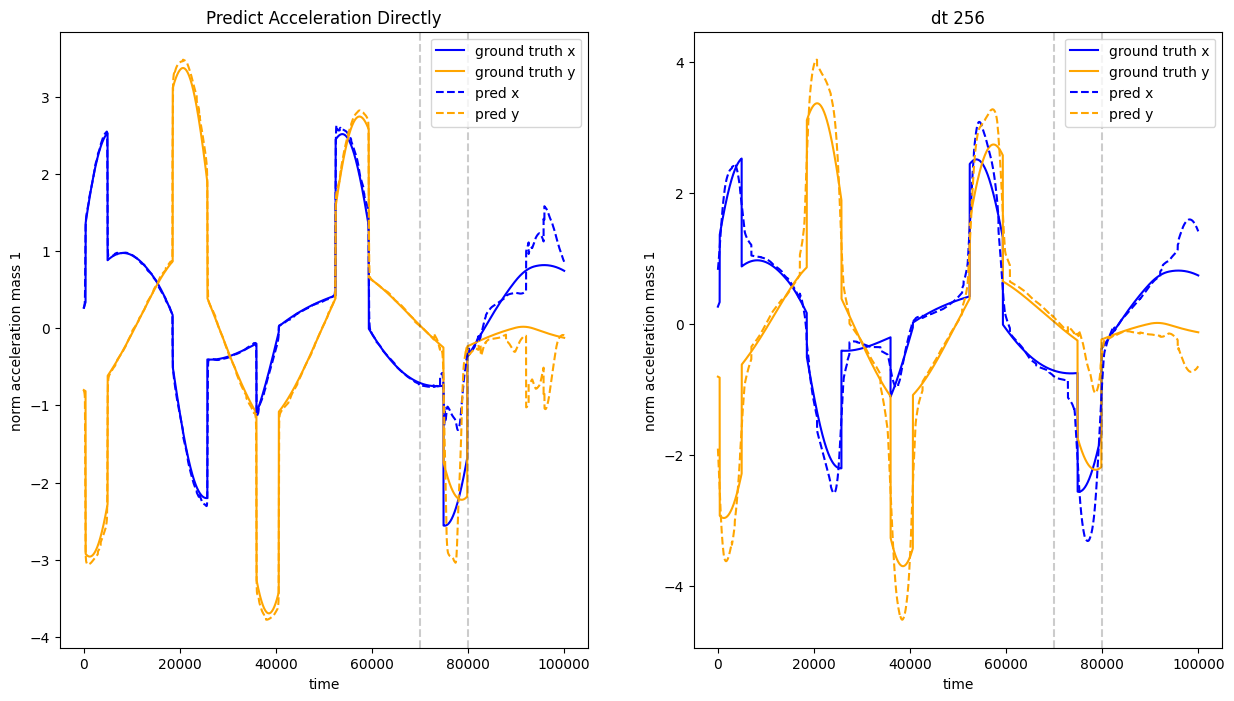

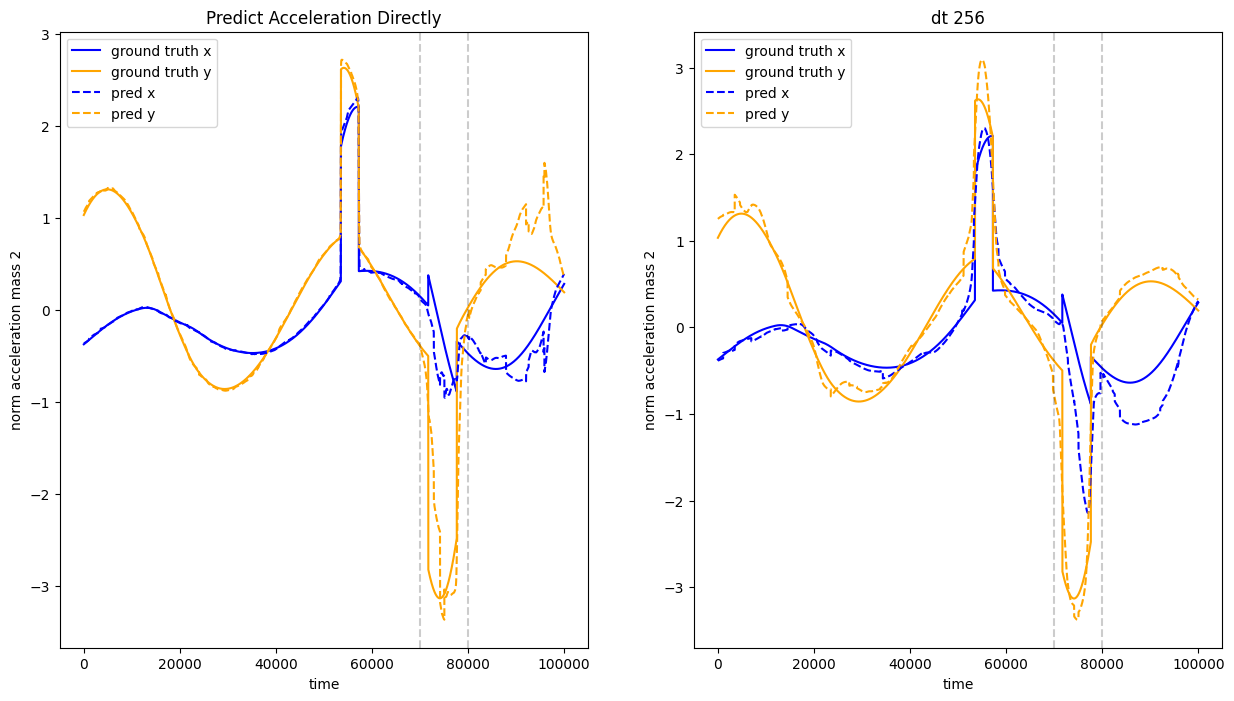

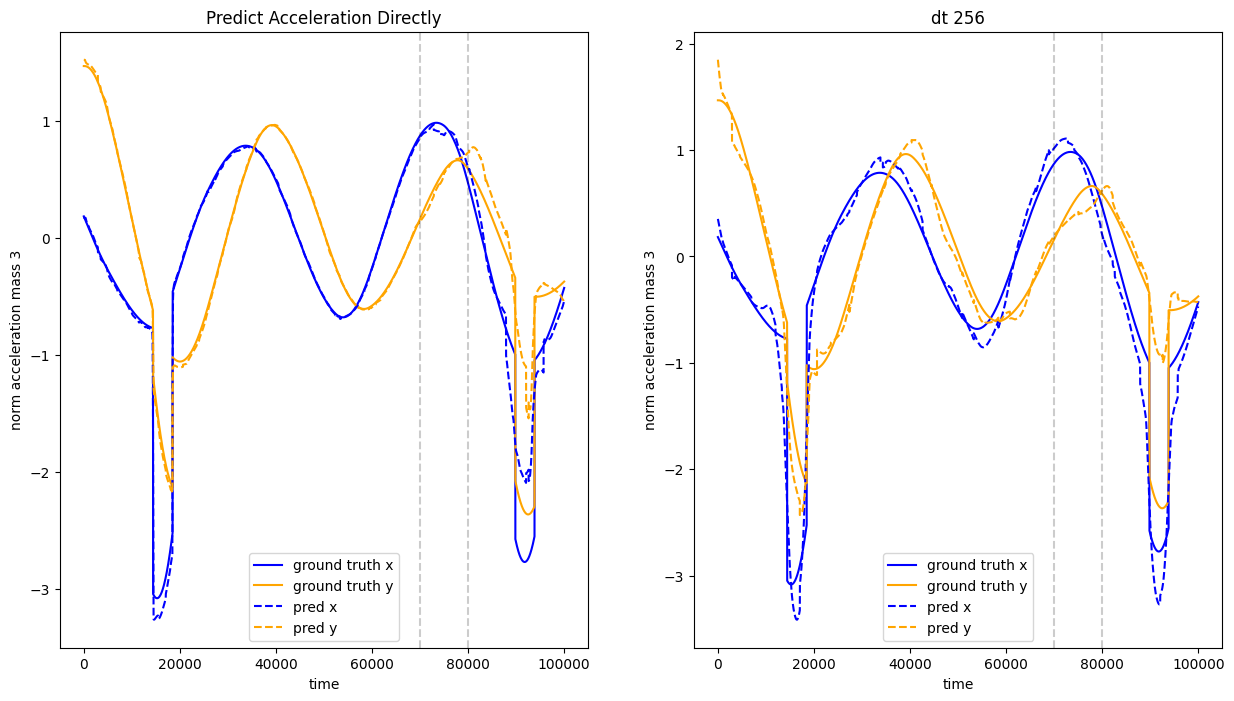

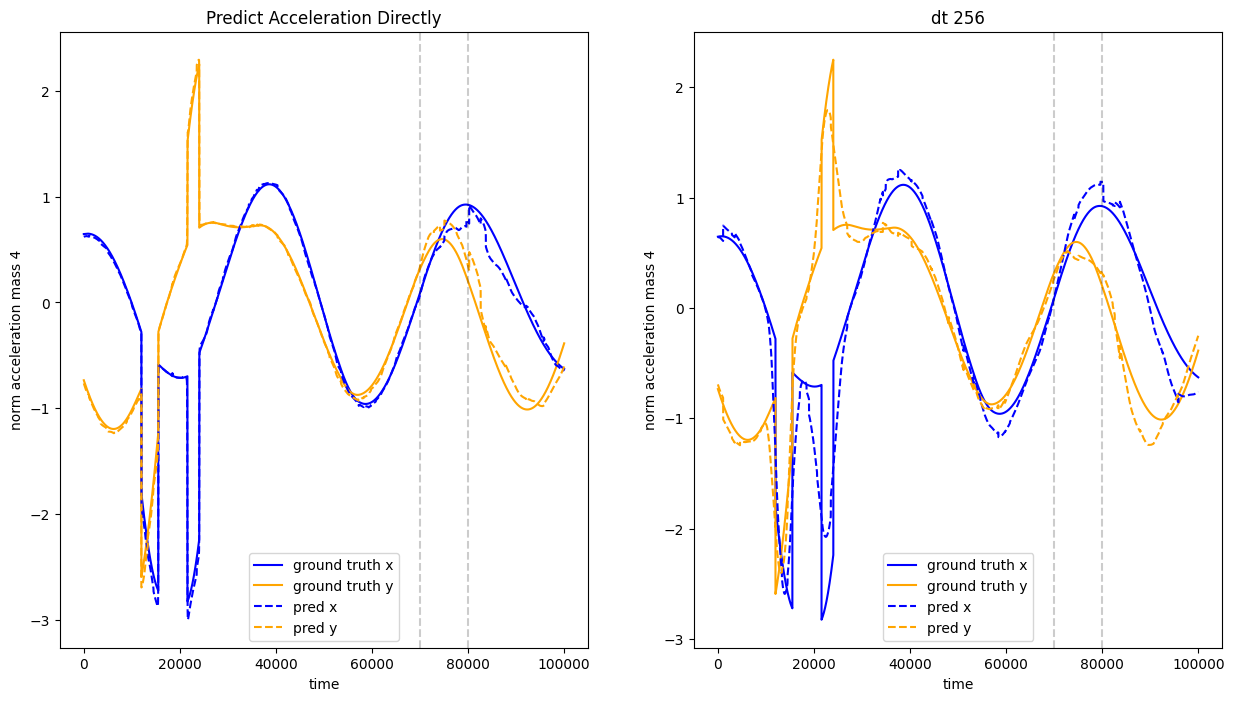

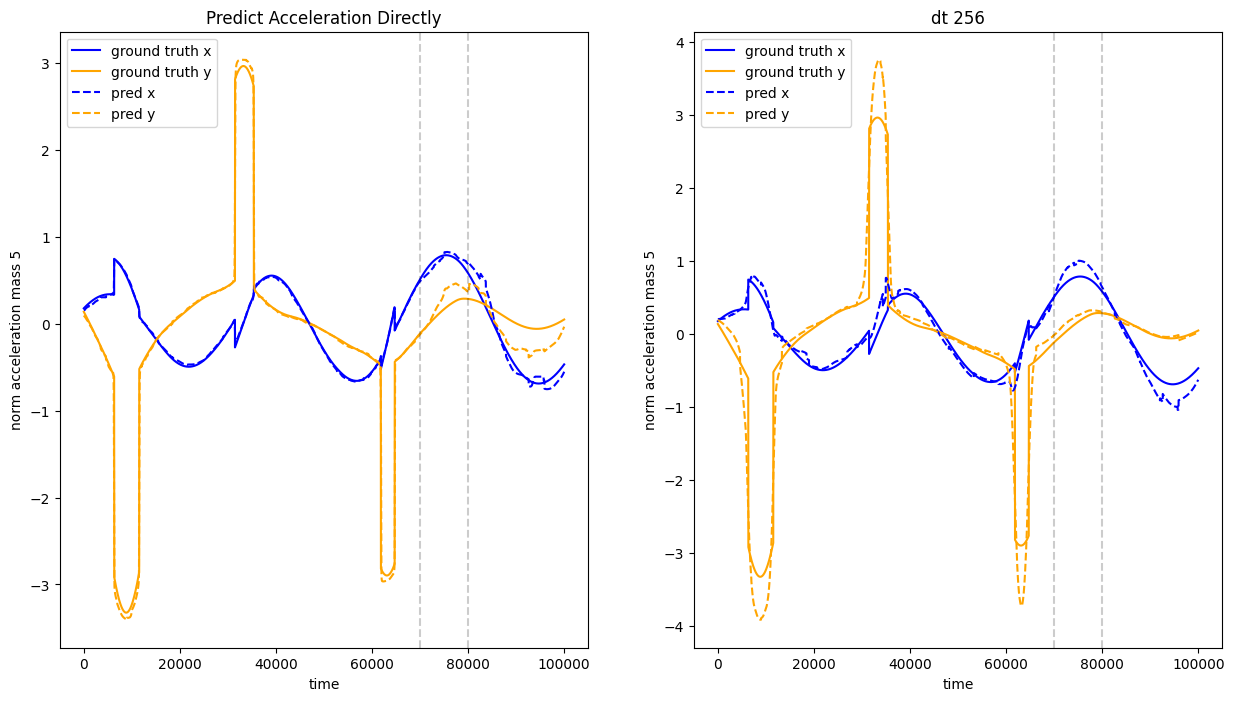

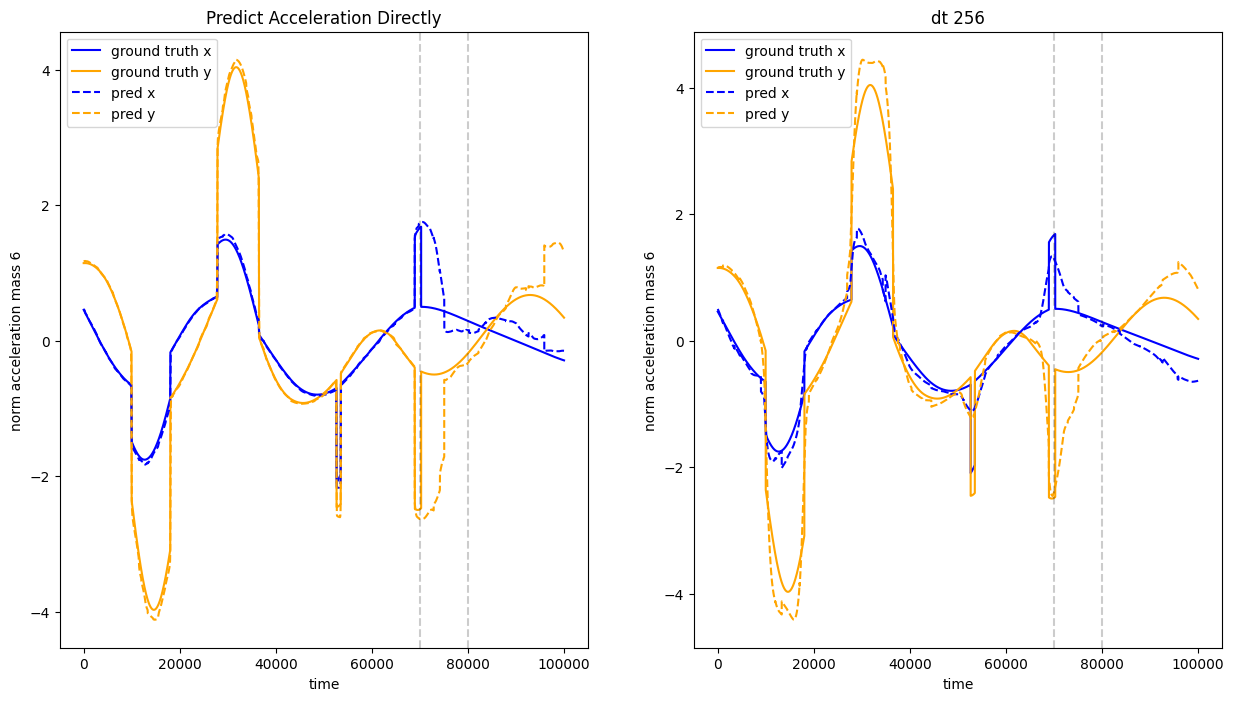

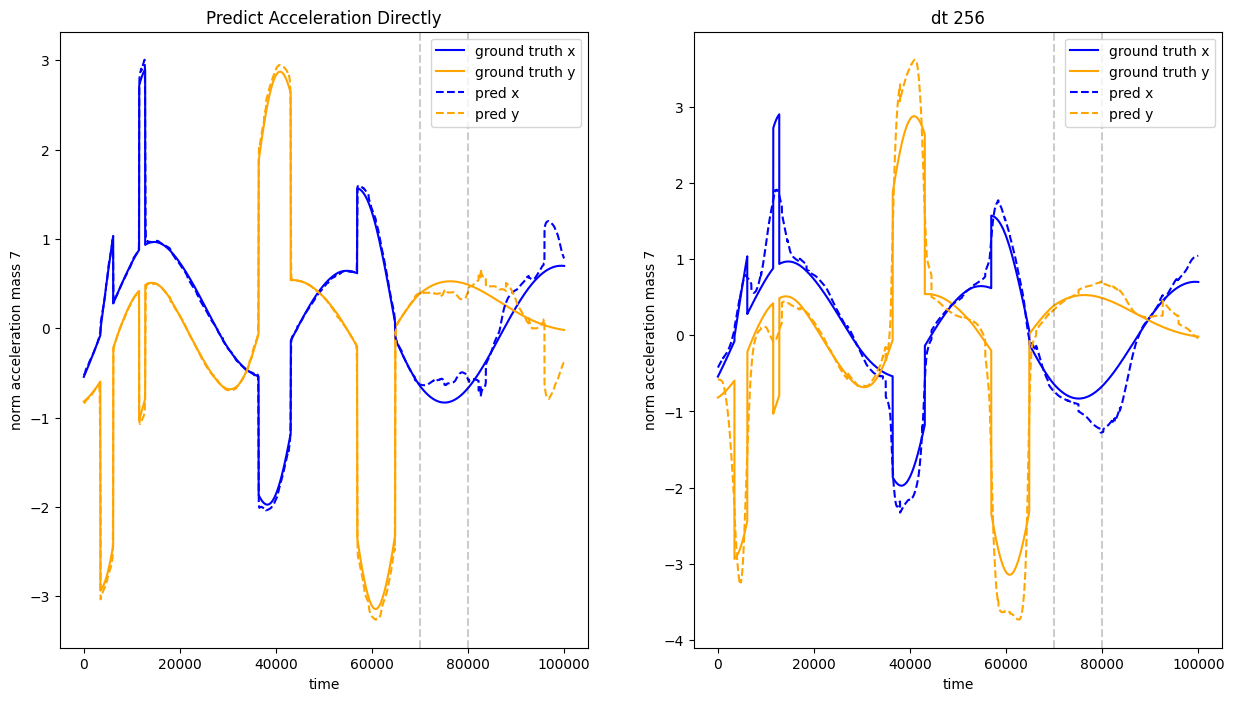

In [41]:
for i in range(acc_over_time.shape[-2]):
    fig, axs = plt.subplots(1, 2, figsize=(15, 8))
    axs[0].plot(range(len(acc_over_time[:,i,0].cpu().numpy())), acc_over_time[:,i,0].cpu().numpy(), label="ground truth x", color='blue')
    axs[0].plot(range(len(acc_over_time[:,i,0].cpu().numpy())), acc_over_time[:,i,1].cpu().numpy(), label="ground truth y", color='orange')
    axs[1].plot(range(len(acc_over_time[:,i,0].cpu().numpy())), acc_over_time[:,i,0].cpu().numpy(), label="ground truth x", color='blue')
    axs[1].plot(range(len(acc_over_time[:,i,0].cpu().numpy())), acc_over_time[:,i,1].cpu().numpy(), label="ground truth y", color='orange')

    axs[0].plot(range(len(acc_pred_acc[:,i,0].cpu().numpy())), acc_pred_acc[:,i,0].cpu().numpy(), label="pred x", linestyle='--', color='blue')
    axs[0].plot(range(len(acc_pred_acc[:,i,0].cpu().numpy())), acc_pred_acc[:,i,1].cpu().numpy(), label="pred y", linestyle='--', color='orange')
    axs[0].set_title('Predict Acceleration Directly')

    axs[1].plot(range(len(acc_pred_acc[:,i,0].cpu().numpy())), acc_pred_pos[:,i,0].cpu().numpy(), label="pred x", linestyle='--', color='blue')
    axs[1].plot(range(len(acc_pred_acc[:,i,0].cpu().numpy())), acc_pred_pos[:,i,1].cpu().numpy(), label="pred y", linestyle='--', color='orange')
    axs[1].set_title('dt 256')

    axs[0].set_xlabel('time')
    axs[0].set_ylabel(f'norm acceleration mass {i}')
    axs[0].legend()
    axs[0].axvline(80000, color='black', linestyle='--', alpha=0.2)
    axs[1].axvline(80000, color='black', linestyle='--', alpha=0.2)
    axs[0].axvline(70000, color='black', linestyle='--', alpha=0.2)
    axs[1].axvline(70000, color='black', linestyle='--', alpha=0.2)
    axs[1].set_xlabel('time')
    axs[1].set_ylabel(f'norm acceleration mass {i}')
    axs[1].legend()